In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully")
print(f"pandas version:{pd.__version__}")
print(f"sqlite3 version: {sqlite3.version}")


All libraries imported successfully
pandas version:2.2.2
sqlite3 version: 2.6.0


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Divyadharshiny-codebooster-internship-2026/student_performance.csv')

In [ ]:
print(f"Dataset loaded:{df.shape[0]}students, {df.shape[1]}column")
print(f"Columns : {df.columns.tolist()}")
df.head(3)

Dataset loaded:30students, 13column
Columns : ['student_id', 'name', 'age', 'gender', 'department', 'semester', 'math_score', 'science_score', 'english_score', 'programming_score', 'attendance_percentage', 'city', 'admission_year']


,student_id,name,age,gender,department,semester,math_score,science_score,english_score,programming_score,attendance_percentage,city,admission_year
0,1001,Aarav Sharma,19,Male,Computer Science,2,85,78,72,91,92,Mumbai,2023
1,1002,Priya Patel,20,Female,Computer Science,2,76,82,88,79,87,Ahmedabad,2023
2,1003,Rohit Verma,19,Male,Electronics,2,65,74,61,55,78,Delhi,2023


In [ ]:
print(df.shape[1])
print(df.shape[0])

13
30


In [ ]:
conn = sqlite3.connect('college.db')
cursor = conn.cursor()
df.to_sql (
    'students',
    conn,
    if_exists = 'replace',
    index = False
)
cursor.execute("SELECT COUNT(*) FROM students")
count = cursor.fetchone()[0]
print(f"Database 'college.db' create successfully")
print(f"Table 'students' has {count} rows")

Database 'college.db' create successfully
Table 'students' has 30 rows


In [ ]:
cursor.execute("PRAGMA table_info(students)")
columns_info = cursor.fetchall()
print("Table structure of 'students' :")
print(f"{'column name':<25} {'Data Type':<12}")
print("_" * 38)
for col in columns_info:
  print(f"{col[1]:<25} {col[2]:<12}")

Table structure of 'students' :
column name               Data Type   
______________________________________
student_id                INTEGER     
name                      TEXT        
age                       INTEGER     
gender                    TEXT        
department                TEXT        
semester                  INTEGER     
math_score                INTEGER     
science_score             INTEGER     
english_score             INTEGER     
programming_score         INTEGER     
attendance_percentage     INTEGER     
city                      TEXT        
admission_year            INTEGER     


In [ ]:
def run_query(sql, description=""):
  if description:
    print(f"\n{'='*55}")
    print(f"{description}")
    print(f" {'='*55}")
  result = pd.read_sql_query(sql, conn)
  print(result.to_string(index=False))
  return result
print("Helper function 'run_query' defined successfully")
print("Usage: run_query(sql_string, description_lable")

Helper function 'run_query' defined successfully
Usage: run_query(sql_string, description_lable


In [ ]:
query1="""
  SELECT student_id, name, department, math_score, attendance_percentage
  FROM students
  LIMIT 10
"""
result=pd.read_sql_query(query1,conn)
result

,student_id,name,department,math_score,attendance_percentage
0,1001,Aarav Sharma,Computer Science,85,92
1,1002,Priya Patel,Computer Science,76,87
2,1003,Rohit Verma,Electronics,65,78
3,1004,Sneha Reddy,Mechanical,70,95
4,1005,Arjun Nair,Computer Science,92,90
5,1006,Meera Joshi,Electronics,58,72
6,1007,Kiran Kumar,Civil,73,85
7,1008,Divya Singh,Computer Science,88,96
8,1009,Rahul Mishra,Mechanical,62,68
9,1010,Ananya Das,Computer Science,95,98


In [ ]:
result1 = run_query(query1, "Query 1 : First 10 students (SELECT + LIMIT)")


Query 1 : First 10 students (SELECT + LIMIT)
 student_id           name       department  math_score  attendance_percentage
       1026     Rekha Nair      Electronics          72                     82
       1027  Gaurav Shukla Computer Science          84                     87
       1028  Sunita Pillai            Civil          60                     73
       1029     Nitin Jain       Mechanical          75                     84
       1030 Akanksha Yadav Computer Science          91                     95


In [ ]:
query2="""
  SELECT student_id, name, department, math_score, attendance_percentage
  FROM students
  LIMIT 5 offset 25
"""

result2 = run_query(query2, "Query 2 : Top 10 students ()")


Query 2 : Top 10 students ()
 student_id           name       department  math_score  attendance_percentage
       1026     Rekha Nair      Electronics          72                     82
       1027  Gaurav Shukla Computer Science          84                     87
       1028  Sunita Pillai            Civil          60                     73
       1029     Nitin Jain       Mechanical          75                     84
       1030 Akanksha Yadav Computer Science          91                     95


In [ ]:
query3 = """
  SELECT name, department, math_score
  FROM students
  order by math_score DESC
  LIMIT 5
"""

result3 = run_query(query3, "Query 3 : Top 5 students by math score")


Query 3 : Top 5 students by math score
          name       department  math_score
    Ananya Das Computer Science          95
   Tanvi Mehta Computer Science          93
    Arjun Nair Computer Science          92
Akanksha Yadav Computer Science          91
Swati Kulkarni Computer Science          90


In [ ]:
query4 = """
  SELECT name, department, programming_score
  FROM students
  where programming_score between 50 and 70
  order by programming_score ASC
  LIMIT 5
"""

result4 = run_query(query4, "Query 4 : Top 5 students by programming score")


Query 4 : Top 5 students by programming score
         name  department  programming_score
   Nitin Jain  Mechanical                 50
Kavya Nambiar  Mechanical                 51
  Meera Joshi Electronics                 52
Preeti Saxena  Mechanical                 53
  Rohit Verma Electronics                 55


In [ ]:
query5 = """
  SELECT name, math_score, science_score, programming_score, attendance_percentage
  FROM students
  WHERE department = 'Computer Science'
  ORDER BY programming_score DESC
"""

result5 = run_query(query5, "Query 5 : Computer Science students by programming score")


Query 5 : Computer Science students by programming score
          name  math_score  science_score  programming_score  attendance_percentage
    Ananya Das          95             89                 97                     98
   Tanvi Mehta          93             90                 96                     97
    Arjun Nair          92             88                 95                     90
Akanksha Yadav          91             93                 94                     95
   Divya Singh          88             91                 93                     96
Swati Kulkarni          90             87                 92                     94
  Aarav Sharma          85             78                 91                     92
     Amit Bose          86             82                 89                     91
    Suresh Rao          83             86                 88                     88
 Gaurav Shukla          84             79                 87                     87
  Nisha Kapoor    

In [ ]:
query5 = """
  SELECT DISTINCT department FROM students
"""

result5 = run_query(query5, " Departments are :")


 Departments are :
      department
Computer Science
     Electronics
      Mechanical
           Civil


In [ ]:
query5 = """
  SELECT DISTINCT department, MAX(programming_score) as programmingscore
  FROM students
  WHERE department in ('Computer Science','Electronics','Civil')
  GROUP BY department
  ORDER BY programming_score DESC
  LIMIT 1
"""

result5 = run_query(query5, "Query 5 : Department with the highest programming score")


Query 5 : Department with the highest programming score
      department  programmingscore
Computer Science                97


In [ ]:
query6 = """
  SELECT name, department, attendance_percentage
  FROM students
  WHERE attendance_percentage > 90
  AND department != 'Civil'
  ORDER BY attendance_percentage DESC
"""

result6 = run_query(query6, "Query 6 : Students with high attendance")
#


Query 6 : Students with high attendance
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91


In [ ]:
query6 = """
  SELECT name, department, attendance_percentage
  FROM students
  WHERE attendance_percentage != (attendance_percentage between 0 and 80)
  ORDER BY attendance_percentage DESC
"""

result6 = run_query(query6, "Query 6 : Students with above 80 percentage attendance")


Query 6 : Students with above 80 percentage attendance
          name       department  attendance_percentage
    Ananya Das Computer Science                     98
   Tanvi Mehta Computer Science                     97
   Divya Singh Computer Science                     96
   Sneha Reddy       Mechanical                     95
Akanksha Yadav Computer Science                     95
Swati Kulkarni Computer Science                     94
  Ritu Agarwal      Electronics                     93
  Aarav Sharma Computer Science                     92
 Kavya Nambiar       Mechanical                     91
     Amit Bose Computer Science                     91
    Arjun Nair Computer Science                     90
  Nisha Kapoor Computer Science                     89
    Suresh Rao Computer Science                     88
   Priya Patel Computer Science                     87
 Gaurav Shukla Computer Science                     87
 Preeti Saxena       Mechanical                     86
   Kiran 

In [ ]:
dept_data = {
    'dept_code' : ['CS', 'ES', 'ME', 'CE'],
    'dept_name' : ['Computer Science', 'Electronic', 'Mechanical', 'Civil'],
    'hod_name' : ['Dr. Sharma', 'Dr.Reddy', 'Dr. Patel', 'Dr. Kumar'],
    'established' : [1985, 1988, 1972, 1965],
    'intake' : [60, 60, 60, 60]
}
dept_df = pd.DataFrame(dept_data)
dept_df

dept_df.to_sql('departments', conn, if_exists='replace', index=False)
print("Created 'department' table:")
print(dept_df.to_string(index=False))
dept_map = {
    'CS' : 'Computer Science',
    'ES' : 'Electronic',
    'ME' : 'Mechanical',
    'CE' : 'Civil'
}
df['dept_code'] = df['department'].map(dept_map)
df.to_sql('students', conn, if_exists='replace', index=False)
print("Updated students table with dept_code column")

Created 'department' table:
dept_code        dept_name   hod_name  established  intake
       CS Computer Science Dr. Sharma         1985      60
       ES       Electronic   Dr.Reddy         1988      60
       ME       Mechanical  Dr. Patel         1972      60
       CE            Civil  Dr. Kumar         1965      60
Updated students table with dept_code column


In [ ]:
query_join="""
select s.name,
s.math_score,
d.dept_name,
d.intake,
d.established
from students AS s
inner join departments as d
on s.dept_code=d.dept_code
order by s.math_score DESC
limit 8
"""
result1=run_query(query_join,"query 13:(select+innerjoin+orderby)")


query 13:(select+innerjoin+orderby)
Empty DataFrame
Columns: [name, math_score, dept_name, intake, established]
Index: []


Text(0.5, 1.0, 'Average Math Score by Department')

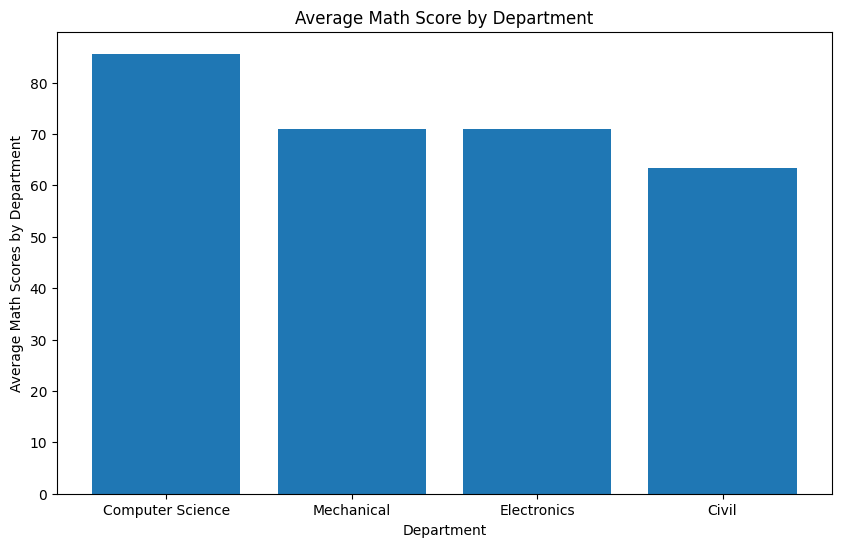

In [ ]:
chart1_sql = """
   SELECT department, ROUND(AVG(math_score), 2) AS avg_math FROM students GROUP BY department ORDER BY avg_math DESC """

chart1_data = pd.read_sql_query(chart1_sql, conn)

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(chart1_data['department'], chart1_data['avg_math'])
ax.set_ylabel('Average Math Scores by Department')
ax.set_xlabel('Department')
ax.set_title('Average Math Score by Department')